# \[Kaggle\] obsessive-compulsive disorder data

SEOYEON CHOI  
2025-11-14

[data
kaggle](https://www.kaggle.com/datasets/ohinhaque/ocd-patient-dataset-demographics-and-clinical-data)

-   The “OCD Patient Dataset: Demographics & Clinical Data” is a
    comprehensive collection of information pertaining to 1500
    individuals diagnosed with Obsessive-Compulsive Disorder (OCD). This
    dataset encompasses a wide range of parameters, providing a detailed
    insight into the demographic and clinical profiles of these
    individuals.
-   Included in this dataset are key demographic details such as age,
    gender, ethnicity, marital status, and education level, offering a
    comprehensive overview of the sample population. Additionally,
    clinical information like the date of OCD diagnosis, duration of
    symptoms, and any previous psychiatric diagnoses are recorded,
    providing context to the patients’ journeys.
-   The dataset also delves into the specific nature of OCD symptoms,
    categorizing them into obsession and compulsion types. Severity of
    these symptoms is assessed using the Yale-Brown Obsessive-Compulsive
    Scale (Y-BOCS) scores for both obsessions and compulsions.
    Furthermore, it documents any co-occurring mental health conditions,
    including depression and anxiety diagnoses.
-   Notably, the dataset outlines the medications prescribed to
    patients, offering valuable insights into the treatment approaches
    employed. It also records whether there is a family history of OCD,
    shedding light on potential genetic or environmental factors.
-   Overall, this dataset serves as a valuable resource for researchers,
    clinicians, and mental health professionals seeking to gain a deeper
    understanding of OCD and its manifestations within a diverse patient
    population.

# Import

In [230]:
import pandas as pd
import numpy as np
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Data

In [231]:
df = pd.read_csv('../../../delete/ocd_patient_dataset.csv')

In [232]:
df.head()

In [233]:
df.columns

Index(['Patient ID', 'Age', 'Gender', 'Ethnicity', 'Marital Status',
       'Education Level', 'OCD Diagnosis Date',
       'Duration of Symptoms (months)', 'Previous Diagnoses',
       'Family History of OCD', 'Obsession Type', 'Compulsion Type',
       'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
       'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications'],
      dtype='object')

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Patient ID                     1500 non-null   int64 
 1   Age                            1500 non-null   int64 
 2   Gender                         1500 non-null   object
 3   Ethnicity                      1500 non-null   object
 4   Marital Status                 1500 non-null   object
 5   Education Level                1500 non-null   object
 6   OCD Diagnosis Date             1500 non-null   object
 7   Duration of Symptoms (months)  1500 non-null   int64 
 8   Previous Diagnoses             1500 non-null   object
 9   Family History of OCD          1500 non-null   object
 10  Obsession Type                 1500 non-null   object
 11  Compulsion Type                1500 non-null   object
 12  Y-BOCS Score (Obsessions)      1500 non-null   int64 
 13  Y-B

# Visualization

-   Age Histogram

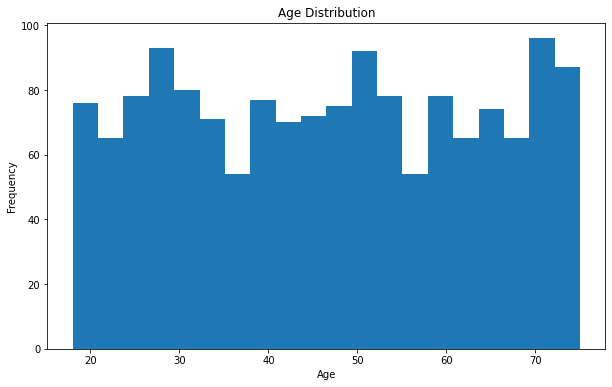

In [235]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'].dropna(), bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [236]:
fig = px.histogram(df, x="Age",
                   nbins=20,
                   title="Age Distribution",
                   labels={"Age": "Age"},
                  width=800, height=600)
fig.show()

-   Gender, Ethnicity & Y-BOCS Score

In [237]:
df.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [238]:
df.Ethnicity.unique()

array(['African', 'Hispanic', 'Asian', 'Caucasian'], dtype=object)

In [239]:
df['Y-BOCS Score (Obsessions)'].values

array([17, 21,  3, ...,  2, 16, 22])

In [240]:
df['Y-BOCS Score (Compulsions)'].values

array([10, 25,  4, ..., 15,  7, 34])

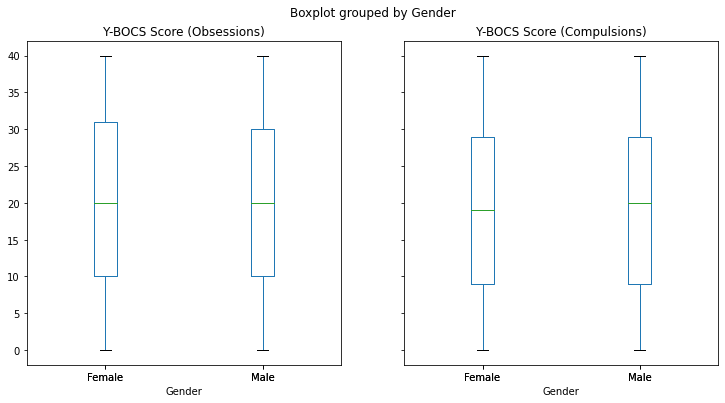

In [241]:
df.boxplot(column=['Y-BOCS Score (Obsessions)','Y-BOCS Score (Compulsions)'], by='Gender', figsize=(12,6), grid=False);

In [242]:
df_long = pd.melt(
    df,
    id_vars='Gender',
    value_vars=['Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)'],
    var_name='Score_Type',
    value_name='Score'
)
fig = px.box(
    df_long,
    x="Gender",
    y="Score",
    color="Score_Type",
    title="Gender-wise Obsessions & Compulsions Scores",
    width=1000,
    height=500
)

fig.show()

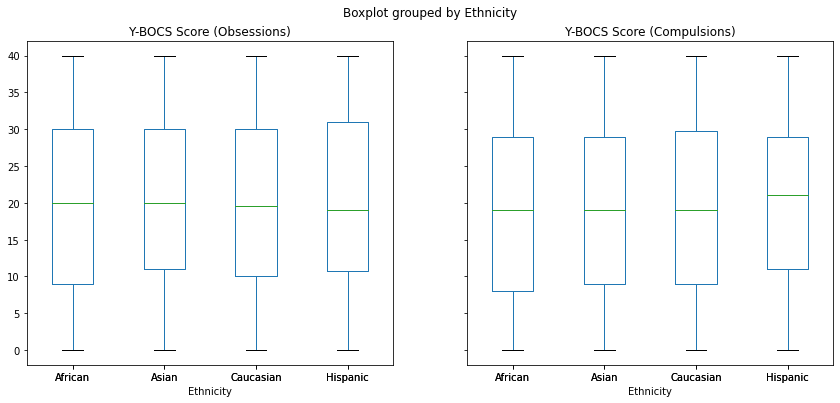

In [243]:
df.boxplot(column=['Y-BOCS Score (Obsessions)','Y-BOCS Score (Compulsions)'], by='Ethnicity', figsize=(14,6), grid=False);

In [244]:
df_long = pd.melt(
    df,
    id_vars='Ethnicity',
    value_vars=['Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)'],
    var_name='Score_Type',
    value_name='Score'
)
fig = px.box(
    df_long,
    x="Ethnicity",
    y="Score",
    color="Score_Type",
    title="Gender-wise Obsessions & Compulsions Scores",
    width=1000,
    height=500
)

fig.show()

-   Obsession Type & Compulsion Type

In [245]:
df['Obsession Type'].value_counts()

Harm-related     333
Contamination    306
Religious        303
Symmetry         280
Hoarding         278
Name: Obsession Type, dtype: int64

In [246]:
df['Compulsion Type'].value_counts()

Washing     321
Counting    316
Checking    292
Praying     286
Ordering    285
Name: Compulsion Type, dtype: int64

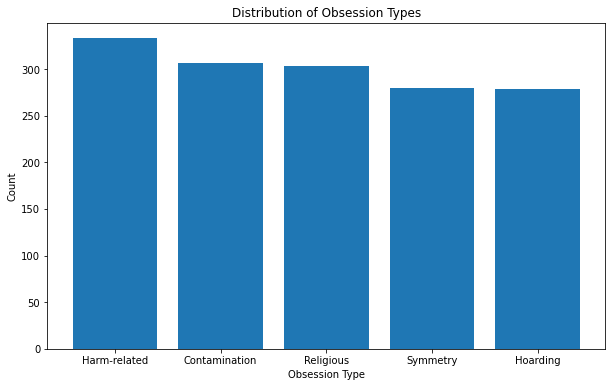

In [247]:
plt.figure(figsize=(10,6))
plt.bar(df['Obsession Type'].value_counts().index, df['Obsession Type'].value_counts().values)
plt.title('Distribution of Obsession Types')
plt.xlabel('Obsession Type')
plt.ylabel('Count')
plt.show()

In [248]:
fig = px.histogram(
    df,
    x="Obsession Type",
    title="Distribution of Obsession Types",
    width=900, height=500
)
fig.update_xaxes(categoryorder='total descending')  
fig.show()

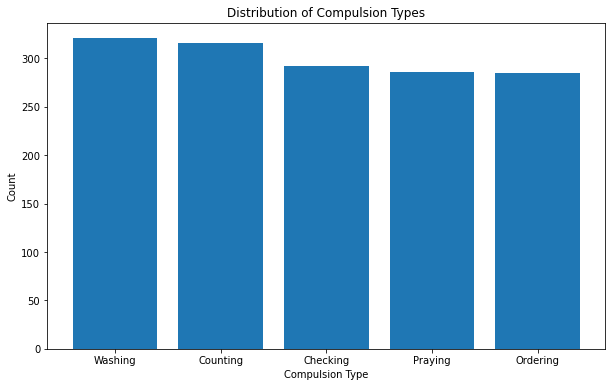

In [249]:
plt.figure(figsize=(10,6))
plt.bar(df['Compulsion Type'].value_counts().index, df['Compulsion Type'].value_counts().values)
plt.title('Distribution of Compulsion Types')
plt.xlabel('Compulsion Type')
plt.ylabel('Count')
plt.show()

In [250]:
fig = px.histogram(
    df,
    x="Compulsion Type",
    title="Distribution of Compulsion Types",
    width=900, height=500
)
fig.update_xaxes(categoryorder='total descending')  
fig.show()

# Clinical Characteristics

-   Y-BOCS Score, Obsessions+Compulsions, deviation of severity (0–7:
    Mild, 8–15: Moderate …)

In [251]:
df['Y-BOCS Score (Total)'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

In [252]:
def classify_severity(score):
    if score <= 7:
        return 'Mild'
    elif score <= 15:
        return 'Moderate'
    elif score <= 23:
        return 'Moderately Severe'
    elif score <= 31:
        return 'Severe'
    else:
        return 'Extreme'

In [253]:
df['Severity'] = df['Y-BOCS Score (Total)'].apply(classify_severity)

In [254]:
df.head()

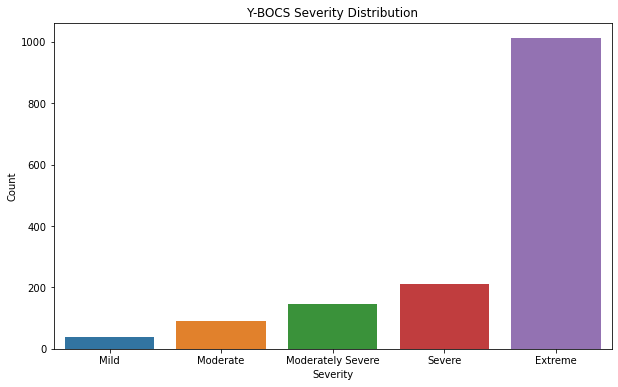

In [255]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Severity', order=['Mild','Moderate','Moderately Severe','Severe','Extreme'])
plt.title('Y-BOCS Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.show()

In [256]:
fig = px.histogram(
    df,
    x='Severity',
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title='Y-BOCS Severity Distribution',
    width=900, height=500
)

fig.show()

-   Duration of Symptoms

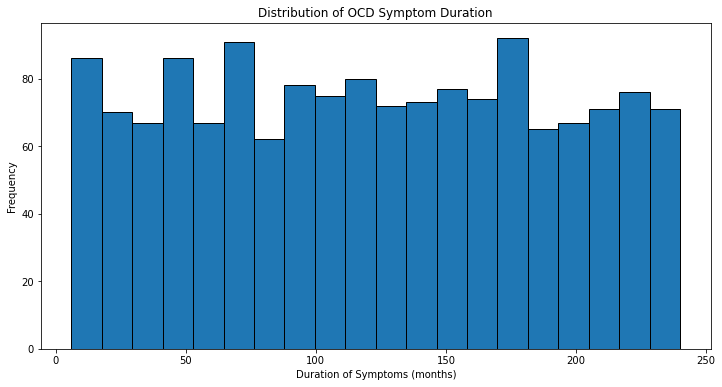

In [257]:
plt.figure(figsize=(12,6))
plt.hist(df['Duration of Symptoms (months)'], bins=20, edgecolor='black')
plt.title('Distribution of OCD Symptom Duration')
plt.xlabel('Duration of Symptoms (months)')
plt.ylabel('Frequency')
plt.show()

In [258]:
fig = px.histogram(
    df,
    x="Duration of Symptoms (months)",
    nbins=20,
    title="Distribution of OCD Symptom Duration",
    width=900, height=500
)
fig.show()

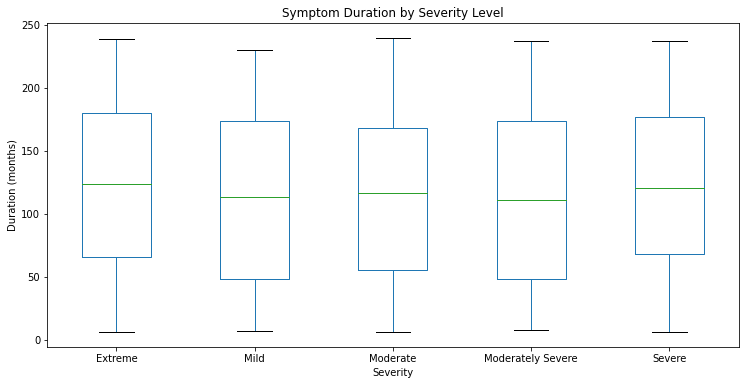

In [259]:
df.boxplot(column='Duration of Symptoms (months)', by='Severity', figsize=(12,6), grid=False)
plt.suptitle('')
plt.title('Symptom Duration by Severity Level')
plt.xlabel('Severity')
plt.ylabel('Duration (months)')
plt.show()

In [260]:
fig = px.box(
    df,
    x="Severity",
    y="Duration of Symptoms (months)",
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title="Symptom Duration by Severity",
    width=1000, height=500
)
fig.show()

-   Previous Diagnoses

In [261]:
df['Previous Diagnoses'].value_counts()

MDD               345
Panic Disorder    313
GAD               298
PTSD              296
None              248
Name: Previous Diagnoses, dtype: int64

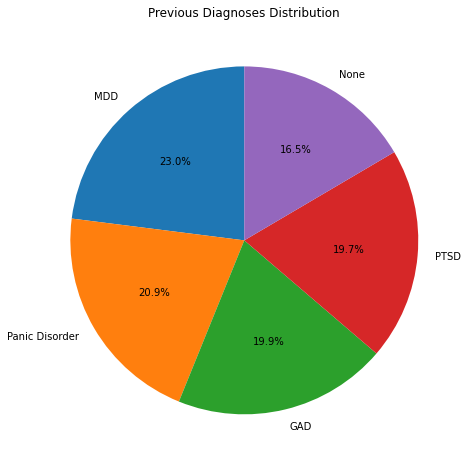

In [262]:
plt.figure(figsize=(8,8))
plt.pie(df['Previous Diagnoses'].value_counts().values, labels=df['Previous Diagnoses'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Previous Diagnoses Distribution')
plt.show()

In [263]:
fig = px.pie(
    df,
    names='Previous Diagnoses',
    title='Previous Diagnoses Distribution',
    hole=0  
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=600, height=600)

fig.show()

-   Family History of OCD

In [264]:
df['Family History of OCD'].value_counts()

Yes    760
No     740
Name: Family History of OCD, dtype: int64

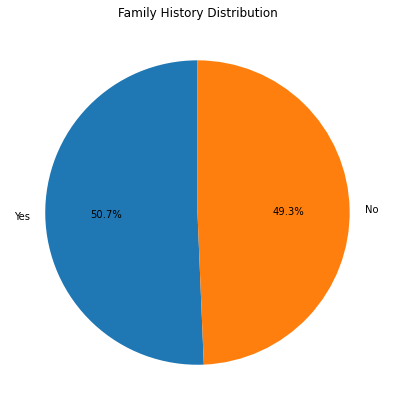

In [265]:
plt.figure(figsize=(7,7))
plt.pie(df['Family History of OCD'].value_counts().values, labels=df['Family History of OCD'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Family History Distribution')
plt.show()

In [266]:
fig = px.pie(
    df,
    names='Family History of OCD',
    title='Family History Distribution',
    hole=0  
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=500, height=500)

fig.show()

# Categorical Relationships

-   Y-BOCS Score, Obsessions+Compulsions

In [268]:
df[['Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']].corr()

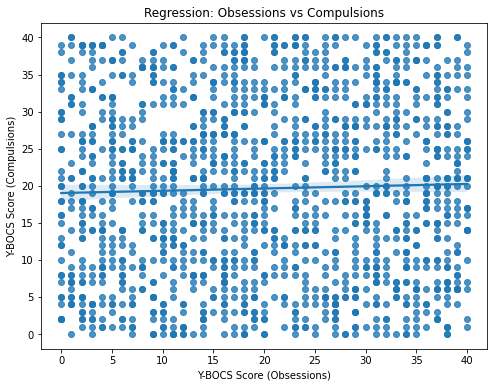

In [271]:
plt.figure(figsize=(8,6))
sns.regplot(
    x='Y-BOCS Score (Obsessions)',
    y='Y-BOCS Score (Compulsions)',
    data=df
)
plt.title('Regression: Obsessions vs Compulsions')
plt.show()

In [273]:
fig = px.scatter(
    df,
    x='Y-BOCS Score (Obsessions)',
    y='Y-BOCS Score (Compulsions)',
    trendline='ols', 
    title='Obsessions vs Compulsions Relationship',
width=500, height=500)
fig.show()

-   Depression Diagnosis, Anxiety Diagnosis & deviation of severity

In [276]:
pd.crosstab(df['Severity'], df['Depression Diagnosis'])

In [278]:
pd.crosstab(df['Severity'], df['Anxiety Diagnosis'])

<Figure size 720x432 with 0 Axes>

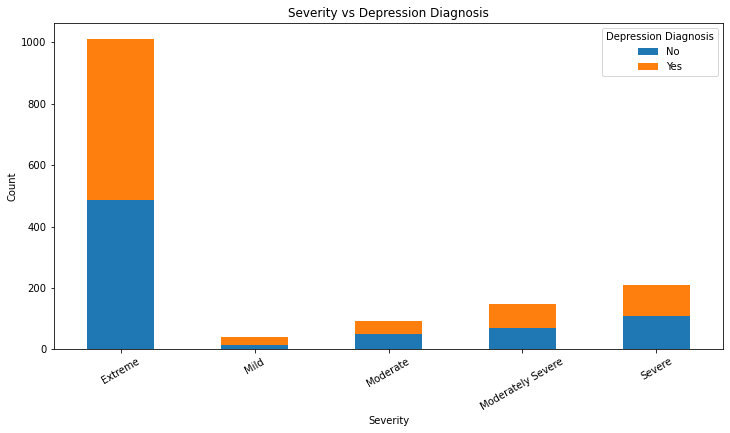

In [279]:
plt.figure(figsize=(10,6))
pd.crosstab(df['Severity'], df['Depression Diagnosis']).plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Severity vs Depression Diagnosis')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

<Figure size 720x432 with 0 Axes>

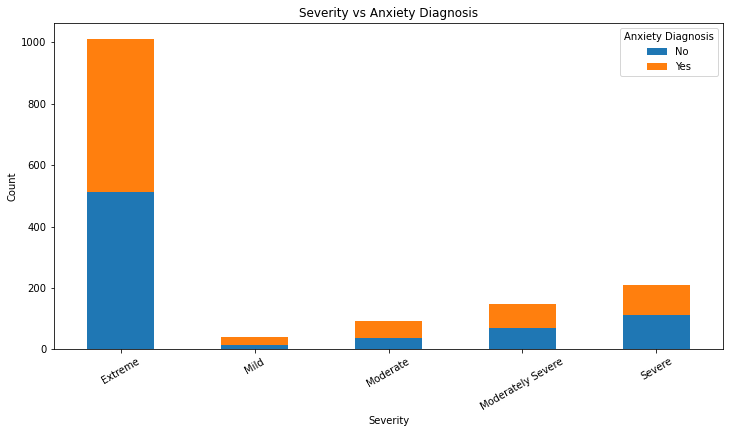

In [280]:
plt.figure(figsize=(10,6))
pd.crosstab(df['Severity'], df['Anxiety Diagnosis']).plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Severity vs Anxiety Diagnosis')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

In [287]:
fig = px.histogram(
    df,
    x='Severity',
    color='Depression Diagnosis',
    barmode='stack',
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title='Severity vs Depression Diagnosis',
width=1200, height=500
)
fig.show()

In [288]:
fig = px.histogram(
    df,
    x='Severity',
    color='Anxiety Diagnosis',
    barmode='stack',
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title='Severity vs Anxiety Diagnosis',
width=1200, height=500
)
fig.show()

-   Medications & deviation of severity

In [290]:
pd.crosstab(df['Severity'], df['Medications'])

In [295]:
fig = px.histogram(
    df,
    x='Severity',
    color='Medications',
    barmode='group',
    category_orders={'Severity': ['Mild','Moderate','Moderately Severe','Severe','Extreme']},
    title='Severity vs Medication Use',
width=1200, height=500
)
fig.show()

# Regression / Predictive Modeling

-   deviation of severity prediction, target=Obsessions+Compulsions

-   Depression Diagnosis, Anxiety Diagnosis classification,
    target=Depression Diagnosis

# Cluster Analysis

-   Obsession Type, Compulsion Type, Y-BOCS, Duration of Symptoms,
    Family History of OCD

# Treatment Pattern

-   character comparison by Medications, checking the difference between
    deviation of severity

-   relationships between Depression Diagnosis, Anxiety Diagnosis &
    Medications

# Symptom trajectory

-   Duration of Symptoms & deviation of severity

# Multi-variable Associations

-   Predicting Y-BOCS total score

-   Family History → Depression/Anxiety diagnosis prediction